<a href="https://colab.research.google.com/github/lehuuphucwork-oss/Baitap_2/blob/main/NNFZ_HW01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.datasets import imdb
import torch

###     Problem 1.1 1D data (Text)      ###
# Load IMDB:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=1000)
# Print the tensor shape of a single review
print("One review length (shape):", (len(review),))
print("\nFirst 20 word IDs:", review[:20])
# Print the review content (decode the integers back to words).
word_index = imdb.get_word_index()
index_to_word = {index + 3: word for word, index in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
decoded_review = " ".join(index_to_word.get(i, "<UNK>") for i in review)
print("Decode integers back to words:")
print(decoded_review[:800], "...")

One review length (shape): (218,)

First 20 word IDs: [1, 14, 22, 16, 43, 530, 973, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25]
Decode integers back to words:
<START> this film was just brilliant casting <UNK> <UNK> story direction <UNK> really <UNK> the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same <UNK> <UNK> as myself so i loved the fact there was a real <UNK> with this film the <UNK> <UNK> throughout the film were great it was just brilliant so much that i <UNK> the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the <UNK> <UNK> was amazing really <UNK> at the end it was so sad and you know what they say if you <UNK> at a film it must have been good and this definitely was also <UNK> to the two little <UNK> that played the <UNK> of <UNK> and paul they were just brilliant children are often left  ...


One image shape (H, W, C): (32, 32, 3)


Text(0.5, 1.0, 'CIFAR-10 sample image')

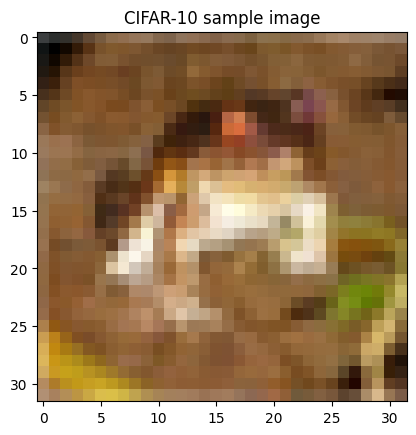

In [17]:
from keras.datasets import cifar10

###     Problem 1.2 2D Data (Image):     ###
# Load the CIFAR-10 dataset.
(x_train_img, y_train_img), (x_test_img, y_test_img) = cifar10.load_data()
# Print the tensor shape (Height, Width, Channel)
img = x_train_img[0]
print("One image shape (H, W, C):", img.shape)
# Display the image using matplotlib.
plt.imshow(img)
plt.title("CIFAR-10 sample image")

Point cloud tensor shape (num_points, 3): (12462, 3)
First 5 points:
 [[-15.94575  -31.3451   -20.13276 ]
 [-15.94575  -31.3451   -20.12697 ]
 [-15.534764  11.7923    -3.3747  ]
 [-15.534734  11.0427    -3.1469  ]
 [ 12.41125  -32.1243   -18.59516 ]]


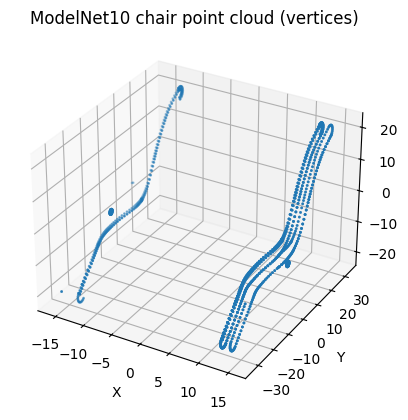

In [37]:
###    Problem 1.3 3D Data (Point Cloud)     ###
import os, glob
from mpl_toolkits.mplot3d import Axes3D
# Download a sample file from the famous ModelNet10 dataset (e.g., a chair or table .off file).
zip_path = tf.keras.utils.get_file("modelnet10.zip","http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip",extract=True,)
DATA_DIR = os.path.join(os.path.dirname(zip_path), "ModelNet10_extracted", "ModelNet10")
sample_off_path = glob.glob(os.path.join(DATA_DIR, "chair", "train", "*.off"))[0]

# Parse the file to extract the (X, Y, Z) coordinates
# Print the tensor shape. It should look like (Number_of_Points,3).
def load_off_vertices(path):
    with open(path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    if lines[0] != "OFF":
        raise ValueError("Not a valid OFF file (missing OFF header).")
    num_vertices, num_faces, _ = map(int, lines[1].split())
    vertices = []
    for i in range(num_vertices):
        x, y, z = map(float, lines[2 + i].split())
        vertices.append([x, y, z])
    return np.array(vertices, dtype=np.float32)
points = load_off_vertices(sample_off_path)
print("Point cloud tensor shape (num_points, 3):", points.shape)
print("First 5 points:\n", points[:5])

#Visualize the points using a 3D scatter plot.
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
max_points = 2000
plot_points = points[:max_points]

ax.scatter(plot_points[:,0], plot_points[:,1], plot_points[:,2], s=1)
ax.set_title("ModelNet10 chair point cloud (vertices)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


In [40]:
video = x_train_img[:10]  # shape (10, 32, 32, 3)
print("Video tensor shape (T, H, W, C):", video.shape)


Video tensor shape (T, H, W, C): (10, 32, 32, 3)
